# Post-hoc C/IER Indicators

Pablo Rogers

In [ ]:

# Load packages for data handling, C/IER indicators, and presentation
suppressPackageStartupMessages({
  library(tidyverse) # Data import, manipulation, and visualization
  library(careless) # Longstring and IRV calculation
  library(gt) # Table formatting; not currently called directly
  library(patchwork) # Composition of multiple ggplot2 plots
  library(modi) # Mahalanobis distance with missing item responses
})


In [ ]:

# Read eligible data from Level 1
imported_data <- suppressMessages(
    read_csv2(
        here::here("Data", "IntermediateData", "whoqol_imported.csv"),
        show_col_types = FALSE
    )
)

# Extract respondent IDs and select scale items for calculation
id_col <- imported_data$ID

items <- imported_data |>
    select(Q1:Q26) |>
    mutate(across(everything(), as.numeric))


## Helper functions definition

In [ ]:

# Laz.R index (Biemann et al., 2025)
calc_lazr <- function(x) {
    tr <- table(x[-length(x)], x[-1], useNA = "ifany")
    sum(tr^2 / rowSums(tr)) / (length(x) - 1)
}

# Kneedle Algorithm (Biemann et al., 2025)
dist2d <- function(a, b, c) {
    v1 <- b - c
    v2 <- a - b
    m <- cbind(v1, v2)
    det(m) / sqrt(sum(v1 * v1))
}

kneedle <- function(values, sign) {
    start <- c(1, values[1])
    end <- c(length(values), values[length(values)])
    which.max(lapply(seq_along(values), function(idx) {
        sign * -1 * dist2d(c(idx, values[idx]), start, end)
    }))
}


## Calculation of the four indicators

The IRV and longstring are calculated using the `careless` package. The Laz.R is calculated through the `calc_lazr` function, and MD is calculated via the `modi` package using the `MDmiss` function to handle missing values.

In [ ]:

# Calculate Laz.R
lazr_vals <- apply(items, 1, calc_lazr)

# Calculate Longstring index
longstr_vals <- longstring(items)

# Calculate Mahalanobis Distance adjusting for missing values
md_vals <- as.numeric(MDmiss(
    data = as.matrix(items),
    center = colMeans(items, na.rm = TRUE),
    cov = cov(items, use = "pairwise.complete.obs")
))

# Calculate Intra-Individual Response Variability (IRV)
irv_vals <- irv(items, split = FALSE)


## Individual variables

In [ ]:

# Consolidate all calculated indicators into a single dataset
df_indicators <- tibble(
    ID      = id_col,
    LazR    = round(lazr_vals, 3),
    Longstr = as.integer(longstr_vals),
    MD      = round(md_vals, 3),
    IRV     = round(irv_vals, 3)
)

df_indicators |>
  head(5) |>
  knitr::kable(
    caption = "First 5 observations of the calculated C/IER indicators"
  )


             ID    LazR   Longstr       MD     IRV
  ------------- ------- --------- -------- -------
    10441016017   0.388         3   49.451   1.474
    10440981694   0.493         5   13.534   0.662
    10440601239   0.493         6   79.044   1.468
    10440562981   0.569         9   27.339   1.294
    10440358563   0.454         8   32.219   1.476

  : First 5 observations of the calculated C/IER indicators


## Univariate visualization

### Laz.R

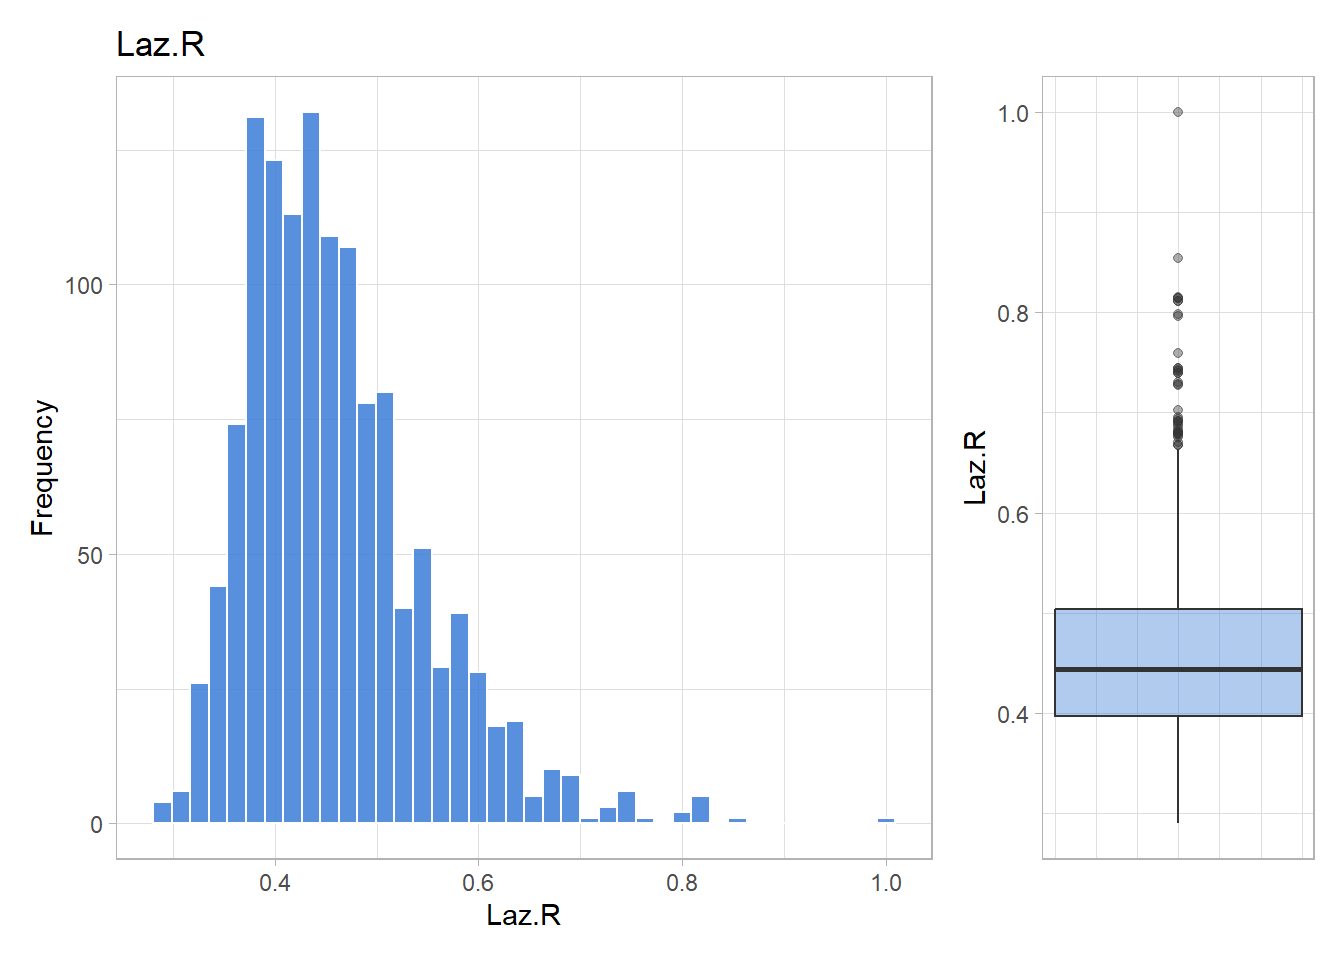

In [ ]:

# Plot histogram and boxplot for Laz.R distribution
p_hist_lazr <- ggplot(df_indicators, aes(x = LazR)) +
    geom_histogram(bins = 40, fill = "#3B7DD8", color = "white", alpha = 0.85) +
    labs(title = "Laz.R", x = "Laz.R", y = "Frequency") +
    theme_light()

p_box_lazr <- ggplot(df_indicators, aes(y = LazR)) +
    geom_boxplot(fill = "#3B7DD8", alpha = 0.4, width = 0.3) +
    labs(title = NULL, y = "Laz.R") +
    theme_light() +
    theme(
        axis.title.x = element_blank(), axis.text.x = element_blank(),
        axis.ticks.x = element_blank()
    )

# Save plot
p_combined_lazr <- p_hist_lazr + p_box_lazr + plot_layout(widths = c(3, 1))
fig_viz_lazr_path <- here::here(
  "Output", "Results", "Figures", "fig-viz-lazr.png"
)
ggsave(fig_viz_lazr_path, p_combined_lazr, width = 8, height = 4)
p_combined_lazr


### Longstring

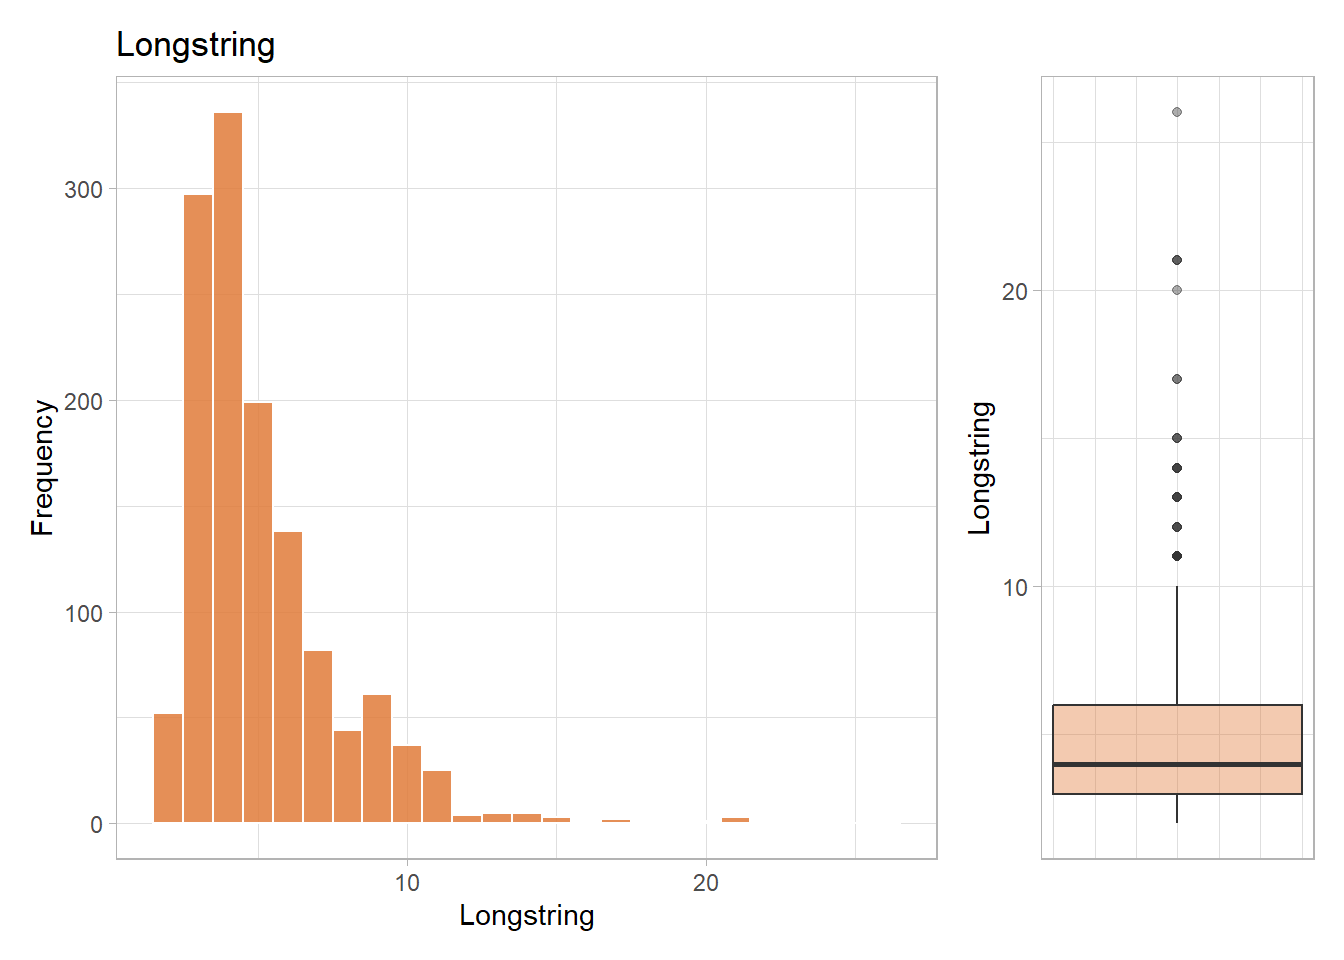

In [ ]:

# Plot histogram and boxplot for Longstring distribution
p_hist_ls <- ggplot(df_indicators, aes(x = Longstr)) +
    geom_histogram(binwidth = 1, fill = "#E07B39", color = "white", alpha = 0.85) +
    labs(title = "Longstring", x = "Longstring", y = "Frequency") +
    theme_light()

p_box_ls <- ggplot(df_indicators, aes(y = Longstr)) +
    geom_boxplot(fill = "#E07B39", alpha = 0.4, width = 0.3) +
    labs(title = NULL, y = "Longstring") +
    theme_light() +
    theme(
        axis.title.x = element_blank(), axis.text.x = element_blank(),
        axis.ticks.x = element_blank()
    )

# Save plot
p_combined_ls <- p_hist_ls + p_box_ls + plot_layout(widths = c(3, 1))
fig_viz_longstr_path <- here::here(
  "Output", "Results", "Figures", "fig-viz-longstr.png"
)
ggsave(fig_viz_longstr_path, p_combined_ls, width = 8, height = 4)
p_combined_ls


### Mahalanobis Distance

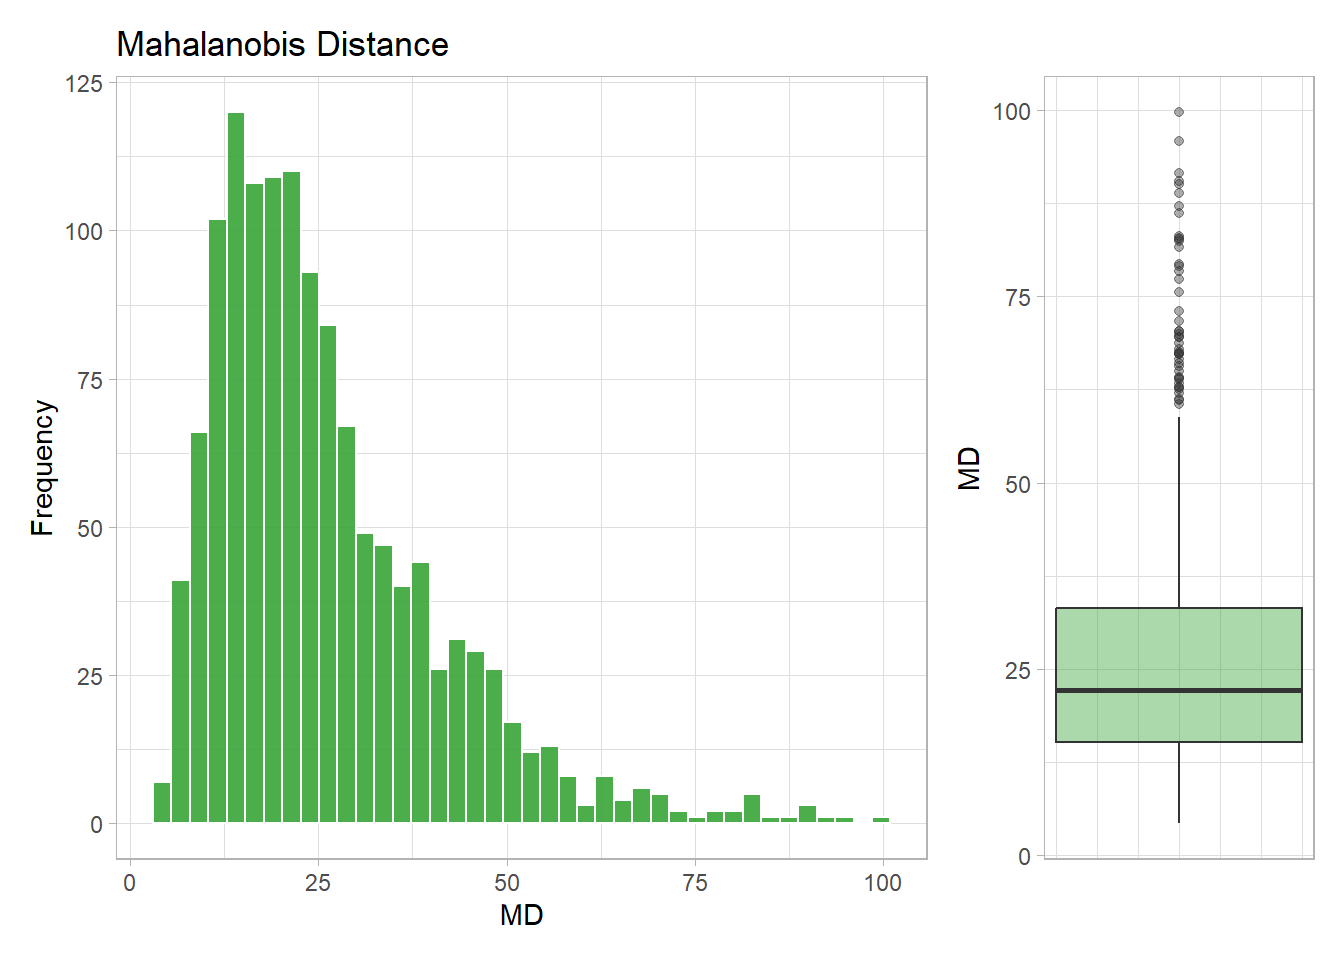

In [ ]:

# Plot histogram and boxplot for Mahalanobis Distance distribution
p_hist_md <- ggplot(df_indicators, aes(x = MD)) +
    geom_histogram(bins = 40, fill = "#2CA02C", color = "white", alpha = 0.85) +
    labs(title = "Mahalanobis Distance", x = "MD", y = "Frequency") +
    theme_light()

p_box_md <- ggplot(df_indicators, aes(y = MD)) +
    geom_boxplot(fill = "#2CA02C", alpha = 0.4, width = 0.3) +
    labs(title = NULL, y = "MD") +
    theme_light() +
    theme(
        axis.title.x = element_blank(), axis.text.x = element_blank(),
        axis.ticks.x = element_blank()
    )

# Save plot
p_combined_md <- p_hist_md + p_box_md + plot_layout(widths = c(3, 1))
fig_viz_md_path <- here::here(
  "Output", "Results", "Figures", "fig-viz-md.png"
)
ggsave(fig_viz_md_path, p_combined_md, width = 8, height = 4)
p_combined_md


### IRV

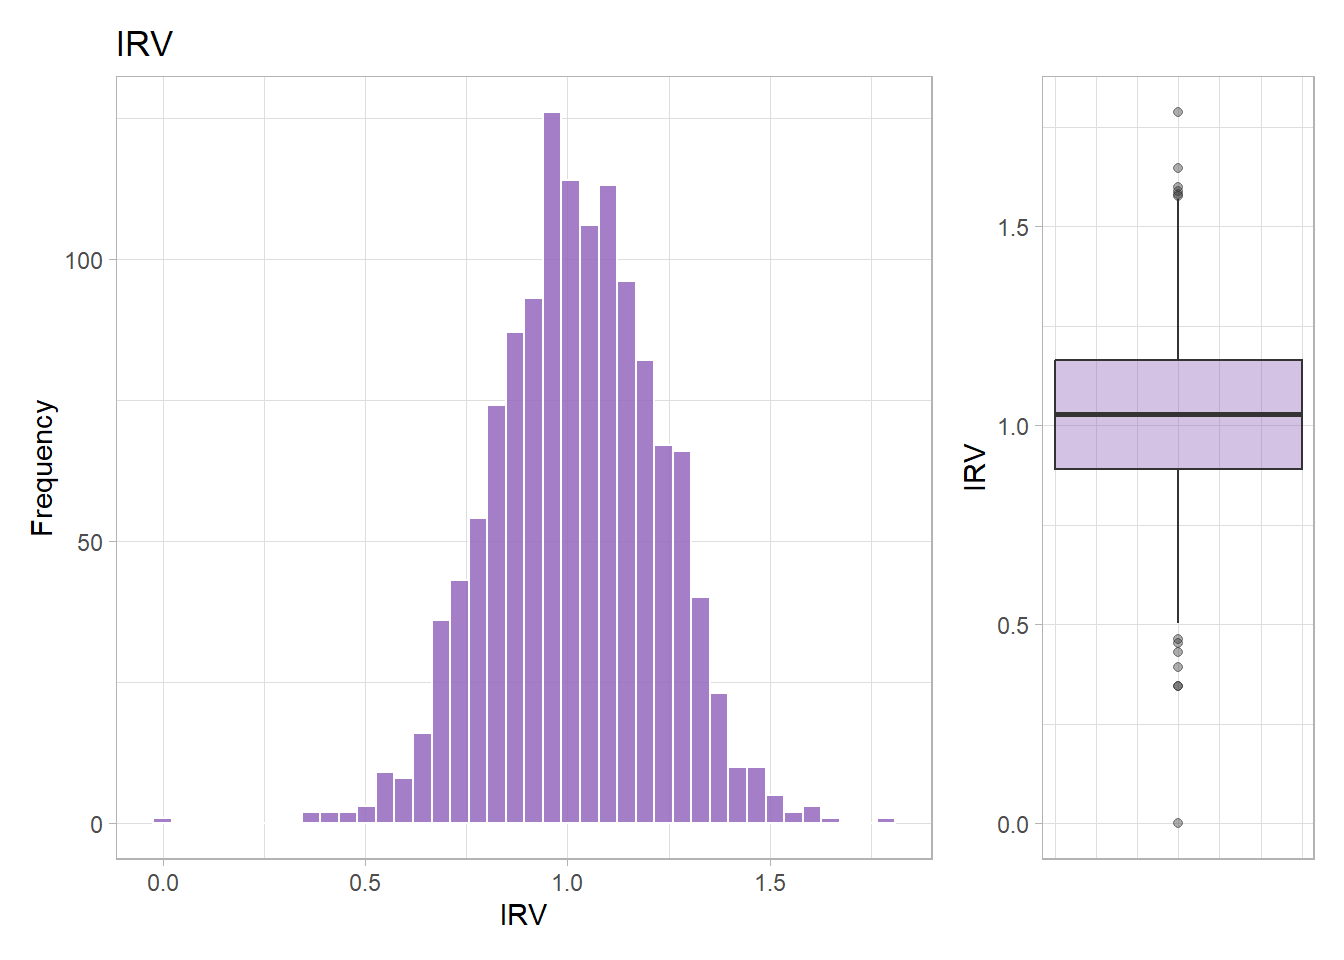

In [ ]:

# Plot histogram and boxplot for IRV distribution
p_hist_irv <- ggplot(df_indicators, aes(x = IRV)) +
    geom_histogram(bins = 40, fill = "#9467BD", color = "white", alpha = 0.85) +
    labs(title = "IRV", x = "IRV", y = "Frequency") +
    theme_light()

p_box_irv <- ggplot(df_indicators, aes(y = IRV)) +
    geom_boxplot(fill = "#9467BD", alpha = 0.4, width = 0.3) +
    labs(title = NULL, y = "IRV") +
    theme_light() +
    theme(
        axis.title.x = element_blank(), axis.text.x = element_blank(),
        axis.ticks.x = element_blank()
    )

# Save plot
p_combined_irv <- p_hist_irv + p_box_irv + plot_layout(widths = c(3, 1))
fig_viz_irv_path <- here::here(
  "Output", "Results", "Figures", "fig-viz-irv.png"
)
ggsave(fig_viz_irv_path, p_combined_irv, width = 8, height = 4)
p_combined_irv


## Cut-off points via Kneedle algorithm

In [ ]:

# Define function to calculate Kneedle point based on sorted values
calc_kneedle <- function(x, sign_val) {
    x_sorted <- sort(x, decreasing = TRUE, na.last = NA)
    n <- length(x_sorted)
    if (n == 0 || sum(x_sorted, na.rm = TRUE) == 0) {
        return(list(pct = NA_real_, crit = NA_real_, sorted = x_sorted))
    }
    pos <- kneedle(x_sorted, sign_val)
    pct <- pos / n
    crit <- quantile(x_sorted, probs = 1 - pct, na.rm = TRUE, names = FALSE)
    list(pct = pct, crit = crit, sorted = x_sorted)
}

# Calculate cut-off points for each indicator
kn_lazr <- calc_kneedle(df_indicators$LazR, -1)
kn_longstr <- calc_kneedle(df_indicators$Longstr, -1)
kn_md <- calc_kneedle(df_indicators$MD, -1)
kn_irv_high <- calc_kneedle(df_indicators$IRV, -1)
kn_irv_low <- calc_kneedle(df_indicators$IRV, +1)

# Tabulate the critical cut-off values and percentage of flagged responses
cutoff_tab <- tibble(
    Indicator = c(
        "Laz.R", "Longstring", "MD",
        "IRV (high end)", "IRV (low end)"
    ),
    `Critical value` = round(c(
        kn_lazr$crit, kn_longstr$crit, kn_md$crit,
        kn_irv_high$crit, kn_irv_low$crit
    ), 2),
    `% flagged` = round(c(
        kn_lazr$pct, kn_longstr$pct, kn_md$pct,
        kn_irv_high$pct, 1 - kn_irv_low$pct
    ) * 100, 1)
)

# Save table
write_csv2(
  cutoff_tab,
  here::here("Output", "Results", "Tables", "tbl-kneedle-cutoffs.csv")
)

# Print table
cutoff_tab |>
    knitr::kable(
        digits  = c(0, 2, 1)
    )


  Indicator          Critical value   \% flagged
  ---------------- ---------------- ------------
  Laz.R                        0.60          6.8
  Longstring                   7.00         14.8
  MD                          40.12         15.4
  IRV (high end)               1.34          4.9
  IRV (low end)                0.69          3.8


## Plots with cut-off points

### Laz.R

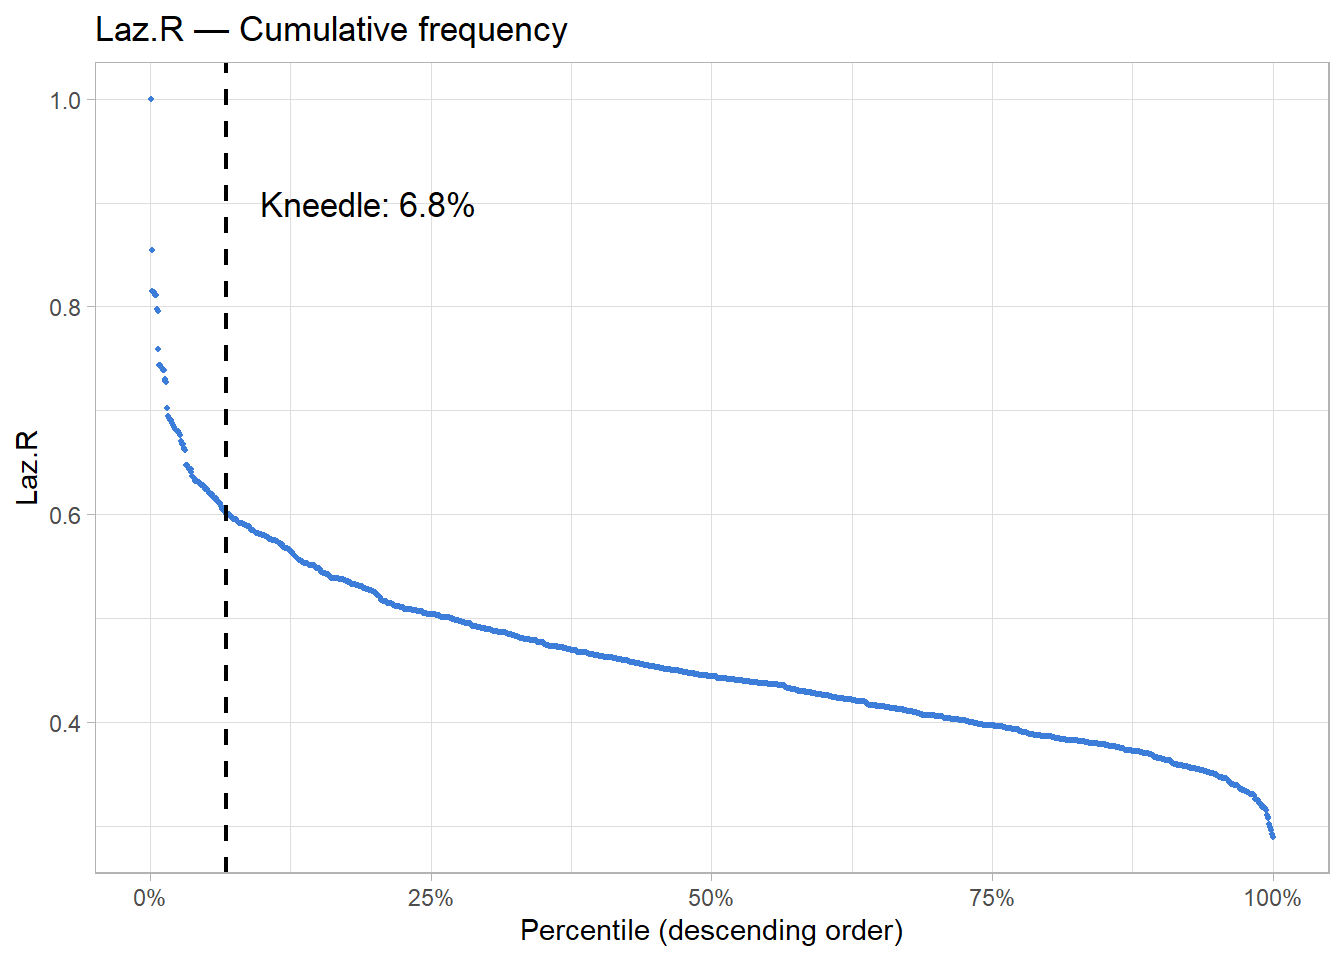

In [ ]:

# Builds the data frame for the cumulative curve (descending order)
make_cum_df <- function(sorted_vals) {
    n <- length(sorted_vals)
    tibble(Index_value = sorted_vals, percent = seq_len(n) / n)
}

# Create cumulative frequency plot for Laz.R with cut-off line
cum_lazr <- make_cum_df(kn_lazr$sorted)

p_cum_lazr <- ggplot(cum_lazr, aes(x = percent, y = Index_value)) +
    geom_point(size = 0.8, color = "#3B7DD8") +
    geom_vline(xintercept = kn_lazr$pct, linetype = "dashed", linewidth = 0.8) +
    annotate("text",
        x = kn_lazr$pct + 0.03, y = max(cum_lazr$Index_value, na.rm = TRUE) * 0.9,
        label = paste0("Kneedle: ", round(kn_lazr$pct * 100, 1), "%"),
        hjust = 0, size = 4.5
    ) +
    scale_x_continuous(labels = scales::percent) +
    labs(
        title = "Laz.R — Cumulative frequency",
        x = "Percentile (descending order)", y = "Laz.R"
    ) +
    theme_light()

# Save plot
fig_cum_lazr_path <- here::here(
  "Output", "Results", "Figures", "fig-cum-lazr.png"
)
ggsave(fig_cum_lazr_path, p_cum_lazr, width = 6, height = 4)
p_cum_lazr


### Longstring

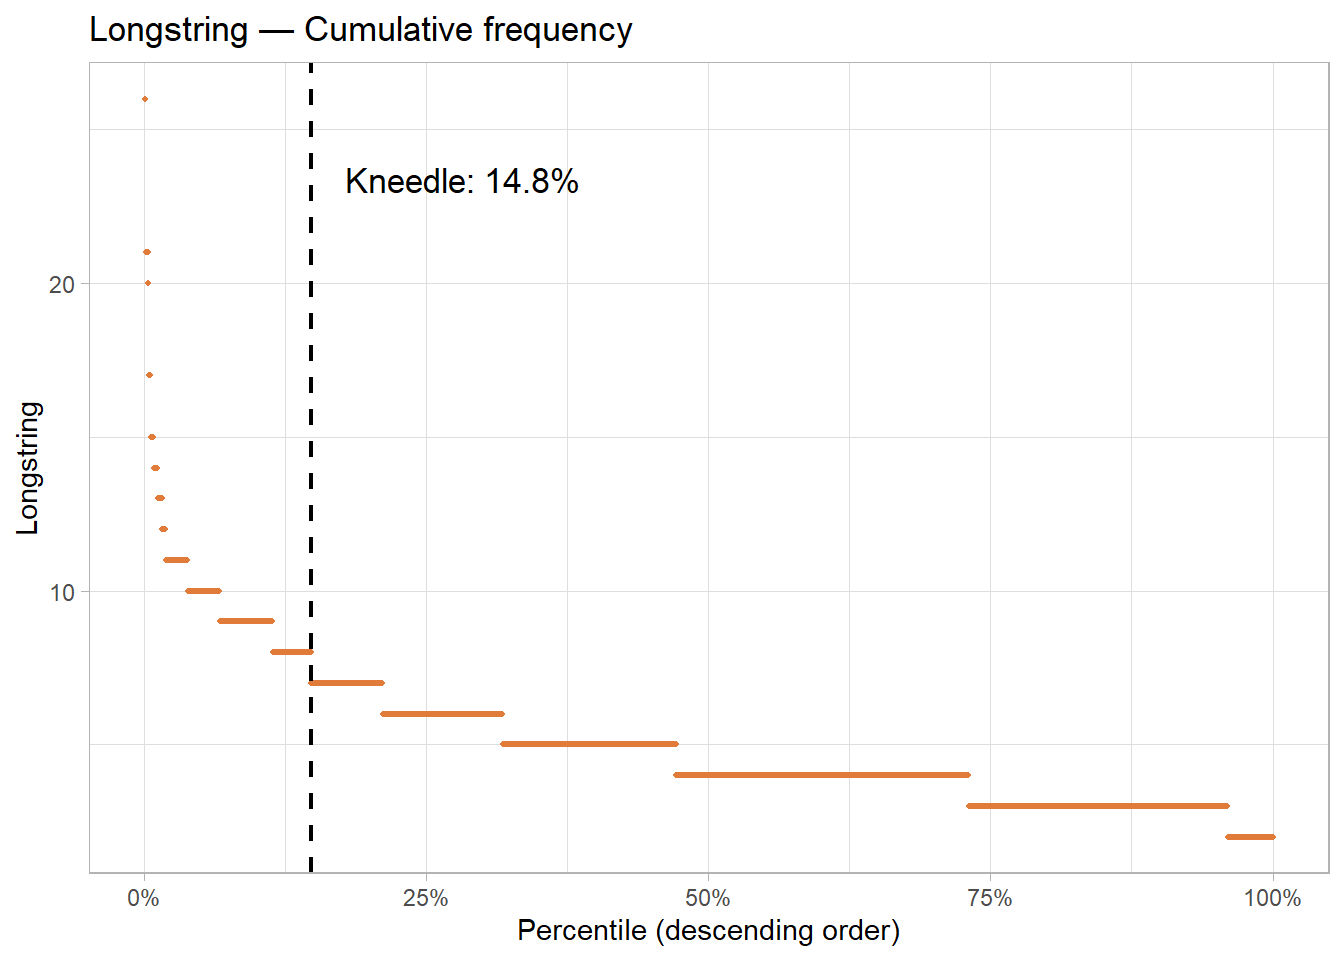

In [ ]:

# Create cumulative frequency plot for Longstring with cut-off line
cum_ls <- make_cum_df(kn_longstr$sorted)

p_cum_ls <- ggplot(cum_ls, aes(x = percent, y = Index_value)) +
    geom_point(size = 0.8, color = "#E07B39") +
    geom_vline(xintercept = kn_longstr$pct, linetype = "dashed", linewidth = 0.8) +
    annotate("text",
        x = kn_longstr$pct + 0.03, y = max(cum_ls$Index_value, na.rm = TRUE) * 0.9,
        label = paste0("Kneedle: ", round(kn_longstr$pct * 100, 1), "%"),
        hjust = 0, size = 4.5
    ) +
    scale_x_continuous(labels = scales::percent) +
    labs(
        title = "Longstring — Cumulative frequency",
        x = "Percentile (descending order)", y = "Longstring"
    ) +
    theme_light()

# Save plot
fig_cum_longstr_path <- here::here(
  "Output", "Results", "Figures", "fig-cum-longstr.png"
)
ggsave(fig_cum_longstr_path, p_cum_ls, width = 6, height = 4)
p_cum_ls


### Mahalanobis Distance

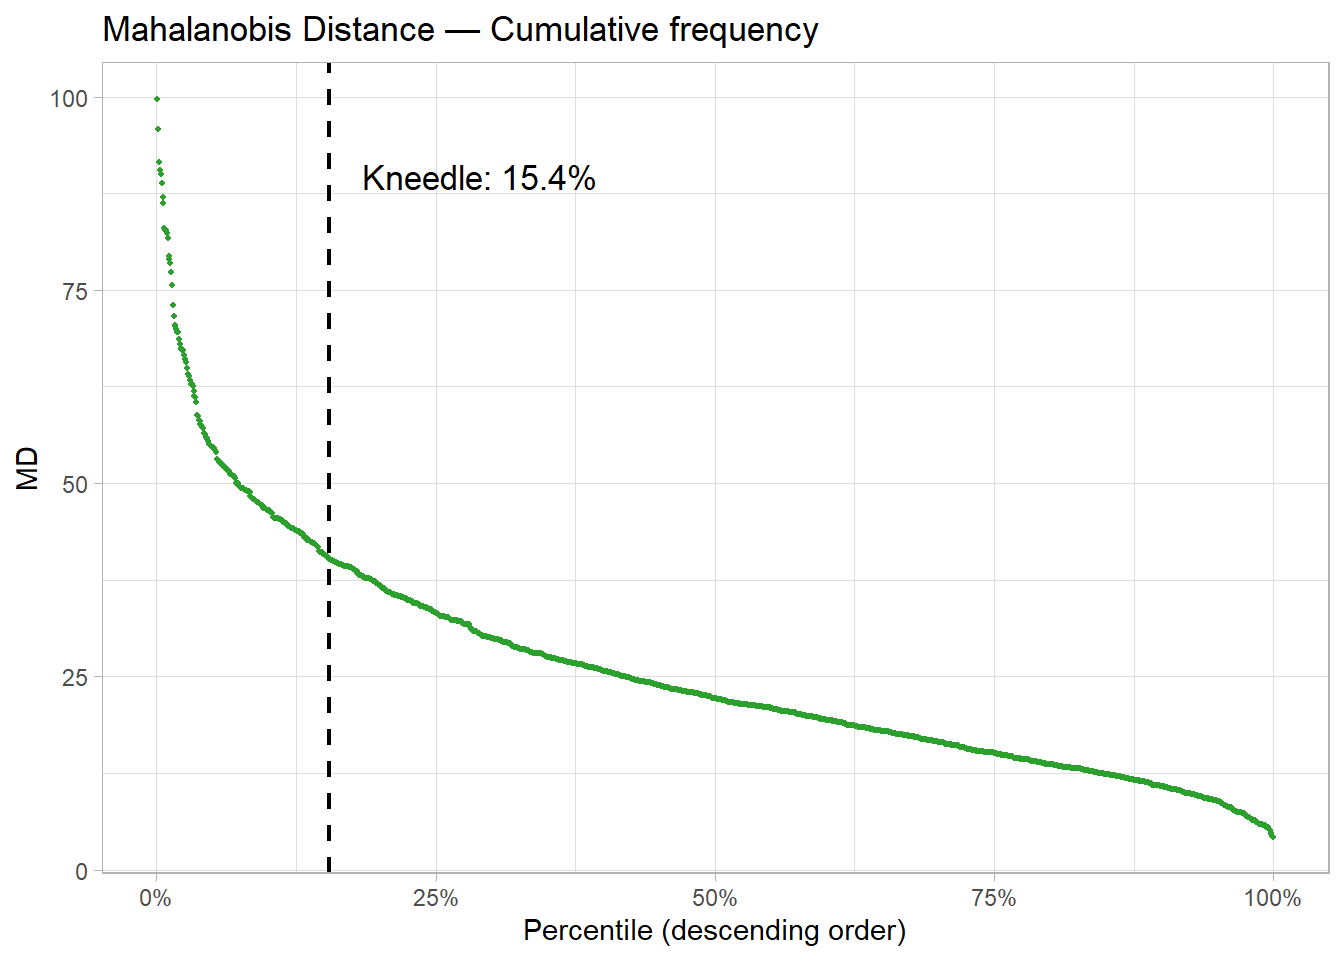

In [ ]:

# Create cumulative frequency plot for Mahalanobis Distance with cut-off line
cum_md <- make_cum_df(kn_md$sorted)

p_cum_md <- ggplot(cum_md, aes(x = percent, y = Index_value)) +
    geom_point(size = 0.8, color = "#2CA02C") +
    geom_vline(xintercept = kn_md$pct, linetype = "dashed", linewidth = 0.8) +
    annotate("text",
        x = kn_md$pct + 0.03, y = max(cum_md$Index_value, na.rm = TRUE) * 0.9,
        label = paste0("Kneedle: ", round(kn_md$pct * 100, 1), "%"),
        hjust = 0, size = 4.5
    ) +
    scale_x_continuous(labels = scales::percent) +
    labs(
        title = "Mahalanobis Distance — Cumulative frequency",
        x = "Percentile (descending order)", y = "MD"
    ) +
    theme_light()

# Save plot
fig_cum_md_path <- here::here(
  "Output", "Results", "Figures", "fig-cum-md.png"
)
ggsave(fig_cum_md_path, p_cum_md, width = 6, height = 4)
p_cum_md


### IRV

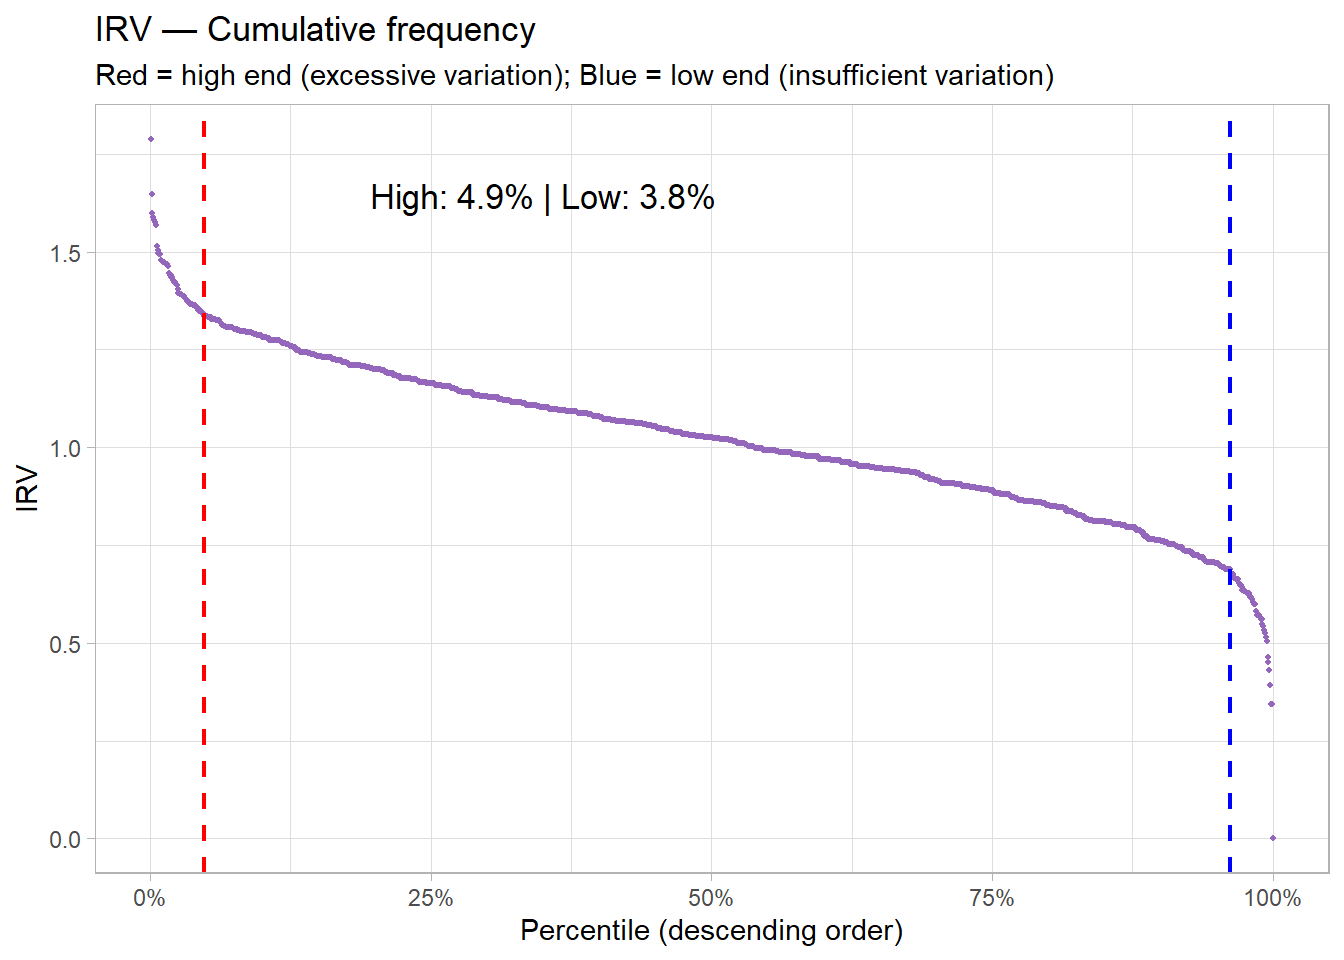

In [ ]:

# Create cumulative frequency plot for IRV with high and low cut-off lines
cum_irv <- make_cum_df(kn_irv_high$sorted)

p_cum_irv <- ggplot(cum_irv, aes(x = percent, y = Index_value)) +
    geom_point(size = 0.8, color = "#9467BD") +
    geom_vline(
        xintercept = kn_irv_high$pct, linetype = "dashed", linewidth = 0.8,
        color = "red"
    ) +
    geom_vline(
        xintercept = kn_irv_low$pct, linetype = "dashed", linewidth = 0.8,
        color = "blue"
    ) +
    annotate("text",
        x = 0.35, y = max(cum_irv$Index_value, na.rm = TRUE) * 0.92,
        label = paste0(
            "High: ", round(kn_irv_high$pct * 100, 1),
            "% | Low: ", round((1 - kn_irv_low$pct) * 100, 1), "%"
        ),
        size = 4.5
    ) +
    scale_x_continuous(labels = scales::percent) +
    labs(
        title = "IRV — Cumulative frequency",
        subtitle = "Red = high end (excessive variation); Blue = low end (insufficient variation)",
        x = "Percentile (descending order)", y = "IRV"
    ) +
    theme_light()

# Save plot
fig_cum_irv_path <- here::here(
  "Output", "Results", "Figures", "fig-cum-irv.png"
)
ggsave(fig_cum_irv_path, p_cum_irv, width = 6, height = 4)
p_cum_irv


## C/IER Flags

In [ ]:

# Generate binary identifiers for respondents exceeding indicator thresholds
df_flags <- df_indicators |>
    mutate(
        LazR_FLAG     = if_else(LazR >= kn_lazr$crit, 1L, 0L),
        Longstr_FLAG  = if_else(Longstr > kn_longstr$crit, 1L, 0L),
        MD_FLAG       = if_else(MD >= kn_md$crit, 1L, 0L),
        IRV_high_FLAG = if_else(IRV >= kn_irv_high$crit, 1L, 0L),
        IRV_low_FLAG  = if_else(IRV <= kn_irv_low$crit, 1L, 0L)
    )

df_flags |>
  head(5) |>
  knitr::kable(
    caption = "First 5 observations of respondent C/IER indicator values and flags"
  )


  --------------------------------------------------------------------------------------------------------------------
             ID    LazR   Longstr       MD     IRV   LazR_FLAG   Longstr_FLAG   MD_FLAG   IRV_high_FLAG   IRV_low_FLAG
  ------------- ------- --------- -------- ------- ----------- -------------- --------- --------------- --------------
    10441016017   0.388         3   49.451   1.474           0              0         1               1              0

    10440981694   0.493         5   13.534   0.662           0              0         0               0              1

    10440601239   0.493         6   79.044   1.468           0              0         1               1              0

    10440562981   0.569         9   27.339   1.294           0              1         0               0              0

    10440358563   0.454         8   32.219   1.476           0              1         0               1              0
  --------------------------------------------------------------------------------------------------------------------

  : First 5 observations of respondent C/IER indicator values and flags


### Flags overview

In [ ]:

# Summarize the count and percentage of flagged respondents globally
table_flags <- df_flags |>
    summarise(
        across(ends_with("_FLAG"), list(
            n_flagged   = \(x) sum(x, na.rm = TRUE),
            pct_flagged = \(x) round(mean(x, na.rm = TRUE) * 100, 1)
        ))
    ) |>
    pivot_longer(everything(),
        names_to = c("Indicator", ".value"),
        names_pattern = "(.+)_(n_flagged|pct_flagged)"
    )

# Save table
write_csv2(
  table_flags,
  here::here("Output", "Results", "Tables", "tbl-flags-overview.csv")
)

# Print table
table_flags |>
    knitr::kable(
        col.names = c("Indicator", "N flagged", "% flagged")
    )


  Indicator         N flagged   \% flagged
  --------------- ----------- ------------
  LazR_FLAG                91          7.0
  Longstr_FLAG            191         14.7
  MD_FLAG                 201         15.5
  IRV_high_FLAG            66          5.1
  IRV_low_FLAG             49          3.8


## From diagnostic flags to final exclusions

The cut-offs above identify response patterns that warrant attention; they do not, by themselves, prove that a respondent answered carelessly. Detection methods are sensitive to different manifestations of C/IER and may also flag unusual but valid response profiles. Consequently, combining every available flag with an **OR** rule can increase sensitivity at the cost of specificity and sample size ([Curran, 2016](#ref-curran2016); [Hong et al., 2020](#ref-hong2020)). Recent evidence also shows that indiscriminate post-hoc removal may distort statistical and psychometric estimates when valid atypical respondents are classified as inattentive ([Wang et al., 2025](#ref-wang2025b)).

### Consequences of alternative decision rules

The following scenarios make the cost of each possible rule explicit. The first two use all five diagnostic flags. The next two remove Longstring from the decision set, while retaining it as a descriptive diagnostic. The final two show the previously considered Laz.R–MD screening alternative.

In [ ]:

all_flags <- c(
  "LazR_FLAG", "Longstr_FLAG", "MD_FLAG",
  "IRV_high_FLAG", "IRV_low_FLAG"
)

decision_flags <- c(
  "LazR_FLAG", "MD_FLAG", "IRV_high_FLAG", "IRV_low_FLAG"
)

df_decisions <- df_flags |>
  mutate(
    n_all_flags = rowSums(pick(all_of(all_flags))),
    n_decision_flags = rowSums(pick(all_of(decision_flags)))
  )

n_eligible <- nrow(df_decisions)

decision_scenarios <- tibble(
  `Decision rule` = c(
    "Any of the five diagnostic flags",
    "At least two of the five diagnostic flags",
    "Any of the four decision flags (excluding Longstring)",
    "At least two of the four decision flags (Plan A)",
    "Laz.R or MD (case-review screening)",
    "Laz.R and MD"
  ),
  Excluded = c(
    sum(df_decisions$n_all_flags >= 1),
    sum(df_decisions$n_all_flags >= 2),
    sum(df_decisions$n_decision_flags >= 1),
    sum(df_decisions$n_decision_flags >= 2),
    sum(df_decisions$LazR_FLAG == 1 | df_decisions$MD_FLAG == 1),
    sum(df_decisions$LazR_FLAG == 1 & df_decisions$MD_FLAG == 1)
  )
) |>
  mutate(
    `% excluded` = round(Excluded / n_eligible * 100, 1),
    Retained = n_eligible - Excluded
  )

write_csv2(
  decision_scenarios,
  here::here("Output", "Results", "Tables", "tbl-decision-scenarios.csv")
)

decision_scenarios |>
  knitr::kable(
    col.names = c("Decision rule", "Excluded", "% excluded", "Retained")
  )


  -------------------------------------------------------------------------------
  Decision rule                                    Excluded         \%   Retained
                                                              excluded 
  ---------------------------------------------- ---------- ---------- ----------
  Any of the five diagnostic flags                      436       33.7        859

  At least two of the five diagnostic flags             139       10.7       1156

  Any of the four decision flags (excluding             344       26.6        951
  Longstring)                                                          

  At least two of the four decision flags (Plan          62        4.8       1233
  A)                                                                   

  Laz.R or MD (case-review screening)                   290       22.4       1005

  Laz.R and MD                                            2        0.2       1293
  -------------------------------------------------------------------------------


<br>

An OR rule across all five flags would remove 436 respondents (33.7%), leaving 859 observations. Even after removing Longstring from the decision set, an OR rule would remove 344 respondents (26.6%). These reductions are difficult to defend when a single post-hoc indicator can produce false positives. In particular, Mahalanobis distance may overflag respondents when ordinal item responses depart from the multivariate-normal assumptions used in conventional outlier detection ([Hong et al., 2020](#ref-hong2020)).

### What the intersections show

Longstring and low IRV are invariability-oriented diagnostics, high IRV targets excessive variation, and MD targets multivariate atypicality. Laz.R detects predictable transitions, including straightlining, alternating, and diagonal response patterns, but it is not a general detector of random responding. Biemann et al. ([2025](#ref-biemann2025)) therefore recommend using Laz.R with complementary approaches and treating the Kneedle cut-off as a basis for scrutiny and possible exclusion rather than as proof of carelessness ([Biemann et al., 2025](#ref-biemann2025)).

In [ ]:

flag_totals <- colSums(df_decisions[all_flags])

pairwise_overlap <- tribble(
  ~`Indicator 1`, ~`Indicator 2`, ~intersection, ~flag_1, ~flag_2,
  "Laz.R", "Longstring",
    sum(df_decisions$LazR_FLAG == 1 & df_decisions$Longstr_FLAG == 1),
    "LazR_FLAG", "Longstr_FLAG",
  "Laz.R", "MD",
    sum(df_decisions$LazR_FLAG == 1 & df_decisions$MD_FLAG == 1),
    "LazR_FLAG", "MD_FLAG",
  "Laz.R", "IRV high",
    sum(df_decisions$LazR_FLAG == 1 & df_decisions$IRV_high_FLAG == 1),
    "LazR_FLAG", "IRV_high_FLAG",
  "Laz.R", "IRV low",
    sum(df_decisions$LazR_FLAG == 1 & df_decisions$IRV_low_FLAG == 1),
    "LazR_FLAG", "IRV_low_FLAG",
  "Longstring", "MD",
    sum(df_decisions$Longstr_FLAG == 1 & df_decisions$MD_FLAG == 1),
    "Longstr_FLAG", "MD_FLAG",
  "Longstring", "IRV high",
    sum(df_decisions$Longstr_FLAG == 1 & df_decisions$IRV_high_FLAG == 1),
    "Longstr_FLAG", "IRV_high_FLAG",
  "Longstring", "IRV low",
    sum(df_decisions$Longstr_FLAG == 1 & df_decisions$IRV_low_FLAG == 1),
    "Longstr_FLAG", "IRV_low_FLAG",
  "MD", "IRV high",
    sum(df_decisions$MD_FLAG == 1 & df_decisions$IRV_high_FLAG == 1),
    "MD_FLAG", "IRV_high_FLAG",
  "MD", "IRV low",
    sum(df_decisions$MD_FLAG == 1 & df_decisions$IRV_low_FLAG == 1),
    "MD_FLAG", "IRV_low_FLAG",
  "IRV high", "IRV low",
    sum(df_decisions$IRV_high_FLAG == 1 & df_decisions$IRV_low_FLAG == 1),
    "IRV_high_FLAG", "IRV_low_FLAG"
) |>
  mutate(
    `% of indicator 1` = round(intersection / flag_totals[flag_1] * 100, 1),
    `% of indicator 2` = round(intersection / flag_totals[flag_2] * 100, 1)
  ) |>
  select(
    `Indicator 1`, `Indicator 2`, `N intersection` = intersection,
    `% of indicator 1`, `% of indicator 2`
  )

write_csv2(
  pairwise_overlap,
  here::here(
    "Output", "Results", "Tables", "tbl-flag-pairwise-overlap.csv"
  )
)

pairwise_overlap |>
  knitr::kable()


  --------------------------------------------------------------------------
  Indicator 1  Indicator 2  N intersection  \% of indicator  \% of indicator
                                                          1                2
  ------------ ------------ -------------- ---------------- ----------------
  Laz.R        Longstring               76             83.5             39.8

  Laz.R        MD                        2              2.2              1.0

  Laz.R        IRV high                  2              2.2              3.0

  Laz.R        IRV low                  18             19.8             36.7

  Longstring   MD                        8              4.2              4.0

  Longstring   IRV high                 11              5.8             16.7

  Longstring   IRV low                  26             13.6             53.1

  MD           IRV high                 42             20.9             63.6

  MD           IRV low                   0              0.0              0.0

  IRV high     IRV low                   0              0.0              0.0
  --------------------------------------------------------------------------


<br>

The overlap is especially informative for the final decision. Of the 91 Laz.R flags, 76 (83.5%) are also Longstring flags. Counting both in the composite rule would therefore allow one narrow manifestation - repetitive or highly predictable responding - to contribute two votes. Longstring remains useful for teaching and diagnosis, but its narrower scope and empirical redundancy with Laz.R justify excluding it from the final flag count. Conversely, 42 of the 66 IRV-high cases are also flagged by MD, providing convergent evidence for excessive variability or multivariate atypicality.

The Laz.R–MD table also explains why those two indicators alone were not used as an automatic deletion rule.

In [ ]:

lazr_md_intersection <- df_decisions |>
  count(LazR_FLAG, MD_FLAG, name = "N") |>
  mutate(
    Classification = case_when(
      LazR_FLAG == 0 & MD_FLAG == 0 ~ "Neither flag",
      LazR_FLAG == 0 & MD_FLAG == 1 ~ "MD only",
      LazR_FLAG == 1 & MD_FLAG == 0 ~ "Laz.R only",
      LazR_FLAG == 1 & MD_FLAG == 1 ~ "Both Laz.R and MD"
    )
  ) |>
  mutate(`% of sample` = round(N / n_eligible * 100, 1)) |>
  select(Classification, N, `% of sample`)

write_csv2(
  lazr_md_intersection,
  here::here(
    "Output", "Results", "Tables", "tbl-lazr-md-intersection.csv"
  )
)

lazr_md_intersection |>
  knitr::kable()


  Classification           N   \% of sample
  ------------------- ------ --------------
  Neither flag          1005           77.6
  MD only                199           15.4
  Laz.R only              89            6.9
  Both Laz.R and MD        2            0.2


<br>

Only two respondents fail both Laz.R and MD, whereas 199 fail MD only and 89 fail Laz.R only. Thus, requiring both would remove almost no cases, while using either would identify 290 cases (22.4%) for review. The latter can be a useful screening pool when case-by-case inspection is feasible: Laz.R covers predictable nonrandom patterns and MD covers multivariate atypicality. It was not adopted here as an automatic exclusion rule because the two indicators are nearly disjoint in this sample and MD-only evidence is not sufficient to infer carelessness from ordinal responses ([Hong et al., 2020](#ref-hong2020); [Ward & Meade, 2023](#ref-ward2023)).

### Final rule: at least two of four decision flags

The final rule counts **Laz.R, MD, IRV high, and IRV low** and excludes a respondent only when at least two of these four flags are present. This rule is deliberately conservative: it requires corroboration, avoids deletion based on MD alone, and retains IRV as evidence for both insufficient and excessive within-person variability. It also follows the broader recommendation to use multiple, context-appropriate indicators rather than relying blindly on a single index ([Curran, 2016](#ref-curran2016); [Ward & Meade, 2023](#ref-ward2023)).

Hong et al. ([2020](#ref-hong2020)) best-subset simulations support selecting a smaller group of complementary indicators instead of a kitchen-sink combination, although their specific subset and cut-offs are design-dependent and should not be imported unchanged into the WHOQOL-Bref ([Hong et al., 2020](#ref-hong2020)). Plan A is therefore a transparent teaching decision for this dataset, not a universal threshold.

In [ ]:

decision_labels <- c("Laz.R", "MD", "IRV high", "IRV low")

df_decisions <- df_decisions |>
  rowwise() |>
  mutate(
    decision_evidence = str_c(
      decision_labels[c_across(all_of(decision_flags)) == 1],
      collapse = " + "
    )
  ) |>
  ungroup() |>
  mutate(
    CIER_EXCLUDE = if_else(n_decision_flags >= 2, 1L, 0L),
    decision_evidence = if_else(
      CIER_EXCLUDE == 1L,
      decision_evidence,
      NA_character_
    )
  )

posthoc_exclusion_log <- df_decisions |>
  filter(CIER_EXCLUDE == 1L) |>
  select(
    ID, LazR, Longstr, MD, IRV, all_of(all_flags),
    n_decision_flags, decision_evidence
  )

write_csv2(
  posthoc_exclusion_log,
  here::here(
    "Output", "DataAppendixOutput", "Tables",
    "posthoc-exclusion-log.csv"
  )
)

exclusion_patterns <- posthoc_exclusion_log |>
  count(decision_evidence, name = "Excluded") |>
  mutate(`% of exclusions` = round(Excluded / sum(Excluded) * 100, 1)) |>
  arrange(desc(Excluded), decision_evidence)

write_csv2(
  exclusion_patterns,
  here::here(
    "Output", "Results", "Tables", "tbl-posthoc-exclusion-patterns.csv"
  )
)

exclusion_patterns |>
  knitr::kable()


  decision_evidence         Excluded   \% of exclusions
  ----------------------- ---------- ------------------
  MD + IRV high                   41               66.1
  Laz.R + IRV low                 18               29.0
  Laz.R + IRV high                 1                1.6
  Laz.R + MD                       1                1.6
  Laz.R + MD + IRV high            1                1.6


<br>

Plan A removes 62 of the 1,295 eligible respondents (4.8%). The full audit log preserves each excluded ID, indicator value, flag, composite count, and evidence combination in `posthoc-exclusion-log.csv`.

### Final analysis dataset

In [ ]:

# Preserve indicators, flags, and the final decision in the intermediate data
screened_data <- imported_data |>
  select(ID, Q1:Q26) |>
  left_join(
    df_decisions,
    by = join_by(ID),
    relationship = "one-to-one"
  )

write_csv2(
  screened_data,
  here::here("Data", "IntermediateData", "whoqol_screened.csv")
)

# Apply Plan A, then reverse-score negatively keyed WHOQOL-Bref items
final_analysis_data <- screened_data |>
  filter(CIER_EXCLUDE == 0L) |>
  select(ID, Q1:Q26) |>
  mutate(across(c(Q3, Q4, Q26), \(x) 6 - x))

# Export final analytical dataset
write_csv2(
  final_analysis_data,
  here::here("Data", "AnalysisData", "whoqol_analysis.csv")
)

analysis_sample_summary <- tibble(
  Stage = c(
    "Eligible after procedural exclusions",
    "Excluded by Plan A post-hoc rule",
    "Final analysis dataset"
  ),
  N = c(
    nrow(screened_data),
    sum(screened_data$CIER_EXCLUDE),
    nrow(final_analysis_data)
  )
)

write_csv2(
  analysis_sample_summary,
  here::here(
    "Output", "Results", "Tables", "tbl-analysis-sample-summary.csv"
  )
)

stopifnot(
  nrow(screened_data) == 1295L,
  sum(screened_data$CIER_EXCLUDE) == 62L,
  nrow(final_analysis_data) == 1233L,
  !any(final_analysis_data$ID %in% posthoc_exclusion_log$ID)
)

analysis_sample_summary |>
  knitr::kable()


  Stage                                       N
  -------------------------------------- ------
  Eligible after procedural exclusions     1295
  Excluded by Plan A post-hoc rule           62
  Final analysis dataset                   1233


<br>

The final `whoqol_analysis.csv` contains 1,233 respondents, the `ID` column, and `Q1-Q26`. Items Q3, Q4, and Q26 are reverse-scored only after the C/IER indicators have been calculated on the response sequence as administered. For substantive analyses, the unfiltered 1,295-case dataset can be retained as a sensitivity condition. Large changes between filtered and unfiltered results should be reported rather than used to choose whichever cleaning rule produces the preferred result ([Wang et al., 2025](#ref-wang2025b)).

## References

Biemann, T., Koch-Bayram, I. F., Meier-Barthold, M., & Aguinis, H. (2025). Using Markov Chains to Detect Careless Responding in Survey Research. *Organizational Research Methods*, *28*(4), 543–568. <https://doi.org/10.1177/10944281251334778>

Curran, P. G. (2016). Methods for the detection of carelessly invalid responses in survey data. *Journal of Experimental Social Psychology*, *66*, 4–19. <https://doi.org/10.1016/j.jesp.2015.07.006>

Hong, M., Steedle, J. T., & Cheng, Y. (2020). Methods of Detecting Insufficient Effort Responding: Comparisons and Practical Recommendations. *Educ Psychol Meas*, *80*(2), 312–345. <https://doi.org/10.1177/0013164419865316>

Wang, M. D., Xiao, L., & Zang, X. (2025). When Cleaning Data Introduces Bias: A Critical Examination of Post-Hoc Methods in Detecting Insufficient Effort Responding. *Journal of Official Statistics*, *41*(4). <https://doi.org/10.1177/0282423X251337843>

Ward, M. K., & Meade, A. W. (2023). Dealing with Careless Responding in Survey Data: Prevention, Identification, and Recommended Best Practices. *Annu. Rev. Psychol.*, *74*(Volume 74, 2023), 577–596. <https://doi.org/10.1146/annurev-psych-040422-045007>